# California Housing Price Prediction - Machine Learning Project

## Project Overview

The goal of this project is to build a machine learning model that predicts median house prices in California districts using demographic and housing data.

The project demonstrates a complete machine learning workflow including:

- exploratory data analysis
- feature engineering
- preprocessing pipelines
- model training and comparison
- hyperparameter tuning
- feature importance analysis
- unsupervised clustering

The final model is a tuned Random Forest that achieves a Mean Absolute Error (MAE) of approximately $31,758.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
np.random.seed(42)

## Dataset Overview

The California Housing dataset contains information about housing areas in California. 
Each row represents a geographic area rather than an individual house. 
The goal of this project is to predict the median house value based on characteristics such as income, location, and housing statistics.

In [2]:
df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Exploratory Data Analysis (EDA)

In this section we explore the dataset to understand variable distributions, relationships, and potential issues such as missing values.

In [3]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Checking Missing Values

Before building models we check whether the dataset contains missing values that need to be handled.

In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

We observe that the variable `total_bedrooms` contains 207 missing values. 
These will be handled later using median imputation in the preprocessing pipeline.

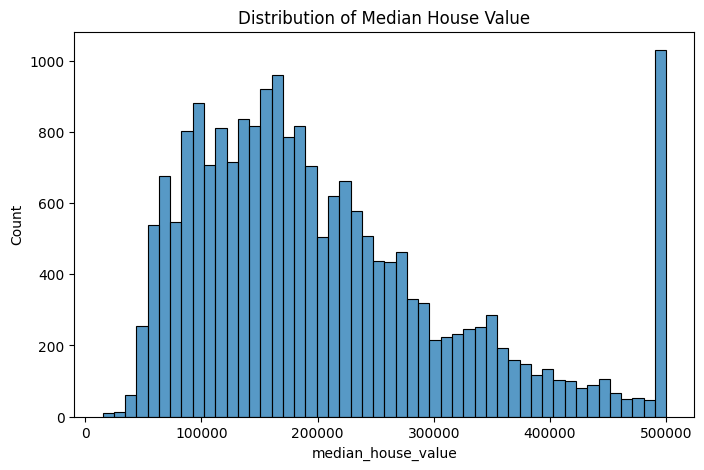

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=50)
plt.title("Distribution of Median House Value")
plt.show()

Distribution of Median House Value

The histogram shows that most housing prices are between 100,000 and 300,000. 
There is a noticeable spike at 500,000, which suggests that values may be capped at this level in the dataset. This may reduce model accuracy for high-value areas.

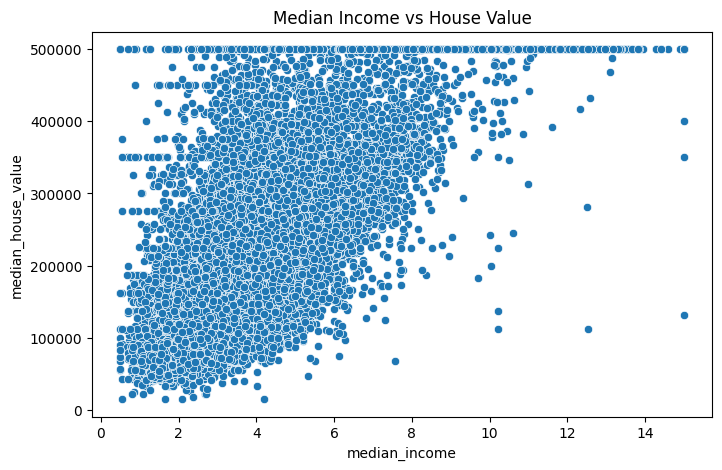

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="median_income", y="median_house_value", data=df)
plt.title("Median Income vs House Value")
plt.show()

Relationship Between Income and House Value

The scatter plot shows a positive relationship between median income and house value. 
Areas with higher income tend to have higher housing prices, suggesting that income is an important predictor.

<Axes: >

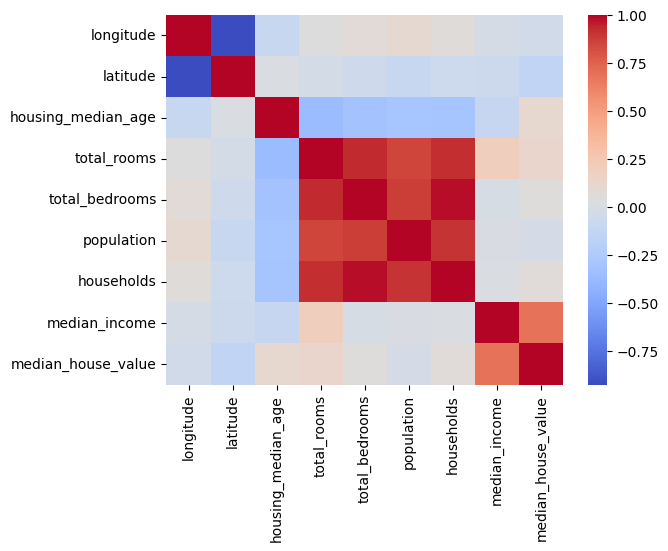

In [8]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")

Correlation Analysis

The heatmap shows that `median_income` has the strongest positive correlation with `median_house_value`. 
Some housing variables such as `total_rooms`, `total_bedrooms`, and `households` are also strongly correlated with each other.

## Feature Engineering

New features are created to better represent housing characteristics.

- `rooms_per_household` measures the average number of rooms per household.
- `bedrooms_per_room` represents the proportion of bedrooms relative to total rooms.
- `population_per_household` indicates how crowded households are.

These features may help the model capture relationships that are not obvious from the original variables.

In [9]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

## Defining Features and Target

The goal of this project is to predict the median house value. 
Therefore, `median_house_value` is used as the target variable (y), while all other variables are used as input features (X).

In [10]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

## Train-Test Split

The dataset is split into training and testing sets. 
The training data is used to train the models, while the test data is kept separate and only used for the final evaluation.

This helps ensure that the model is evaluated on unseen data and reduces the risk of overfitting.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Preprocessing Pipeline

Before training machine learning models, the data needs to be prepared. 
This includes handling missing values, scaling numerical features, and encoding categorical variables.

To ensure that preprocessing is applied consistently and without causing data leakage, a preprocessing pipeline is created using scikit-learn.

The pipeline performs the following steps:

Numerical features:
- Missing values are filled using median imputation
- Features are scaled using StandardScaler

Categorical features:
- The variable `ocean_proximity` is encoded using OneHotEncoder

Using a pipeline ensures that preprocessing is learned only from the training data and then applied to the test data.

In [12]:
# Identify numerical and categorical columns

num_features = X.select_dtypes(include=["float64", "int64"]).columns
cat_features = ["ocean_proximity"]

print("Numerical features:")
print(num_features)

print("\nCategorical features:")
print(cat_features)

Numerical features:
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='str')

Categorical features:
['ocean_proximity']


In [13]:
# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

The preprocessing pipeline now handles both numerical and categorical variables.

Numerical variables are first imputed using the median to handle missing values (such as in `total_bedrooms`) and then scaled using StandardScaler.

The categorical variable `ocean_proximity` is encoded using one-hot encoding, which converts each category into a binary column so that machine learning models can process it.

The ColumnTransformer ensures that the correct preprocessing steps are applied to the correct types of features.

## Baseline Model: Linear Regression

A baseline model is created to provide a simple reference point for model performance.

Linear Regression is used as the baseline because it is simple, fast to train, and easy to interpret. 
More complex models will later be compared against this baseline to determine whether they provide better predictive performance.

In [14]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [15]:
baseline_preds = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 49645.49244453642


The baseline Linear Regression model achieved a Mean Absolute Error (MAE) of approximately 49645. This means that on average the model's predictions differ from the actual house values by about 49645 dollars. This baseline performance will be used as a reference when evaluating more complex models.

## Tree-based Models

Decision Tree

Decision Trees are non-linear models that can capture complex relationships between variables. Unlike linear regression, decision trees can model interactions between features and do not assume a linear relationship between inputs and the target variable.

In [16]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_preds)

print("Decision Tree MAE:", tree_mae)

Decision Tree MAE: 43092.87088178295


Random Forest

Random Forest is an ensemble method that builds multiple decision trees and combines their predictions. By averaging the predictions of many trees, Random Forest typically reduces overfitting and improves predictive performance compared to a single decision tree.

In [17]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 31926.269672965114


In [18]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [baseline_mae, tree_mae, rf_mae]
})

results["MAE"] = results["MAE"].round(0)
results = results.sort_values("MAE")
results

,Model,MAE
2,Random Forest,31926.0
1,Decision Tree,43093.0
0,Linear Regression,49645.0


The results show that the Random Forest model achieves the lowest MAE among the tested models. This suggests that Random Forest is able to capture complex relationships in the dataset better than Linear Regression and Decision Trees. Therefore, Random Forest will be selected for further optimization using hyperparameter tuning.

## Model Evaluation and Cross-Validation

To obtain a more reliable estimate of model performance, cross-validation is used on the training dataset.

Cross-validation works by splitting the training data into several smaller subsets (folds). The model is trained multiple times, each time using a different subset as validation data while the remaining folds are used for training.

In this project, 5-fold cross-validation is used. This means the training data is split into five parts and the model is trained five times. Cross-validation helps provide a more stable estimate of model performance compared to evaluating the model on a single split of the data.

The evaluation metric used is Mean Absolute Error (MAE). MAE is chosen because it measures the average absolute difference between predicted and actual prices, which is easy to interpret in dollar units. It is also less sensitive to extreme outliers than RMSE. 

In [19]:
# Linear Regression pipeline
linreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Decision Tree pipeline
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Run cross-validation (MAE)
linreg_scores = -cross_val_score(linreg_model, X_train, y_train,
                                 scoring="neg_mean_absolute_error", cv=5)

tree_scores = -cross_val_score(tree_model, X_train, y_train,
                               scoring="neg_mean_absolute_error", cv=5)

rf_scores = -cross_val_score(rf_model, X_train, y_train,
                             scoring="neg_mean_absolute_error", cv=5)

In [20]:
# Create cross-validation results table

cv_results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "CV Mean MAE": [
        linreg_scores.mean(),
        tree_scores.mean(),
        rf_scores.mean()
    ],
    "CV Std": [
        linreg_scores.std(),
        tree_scores.std(),
        rf_scores.std()
    ]
})

cv_results["CV Mean MAE"] = cv_results["CV Mean MAE"].round(0)
cv_results["CV Std"] = cv_results["CV Std"].round(0)

cv_results = cv_results.sort_values("CV Mean MAE")

cv_results

,Model,CV Mean MAE,CV Std
2,Random Forest,32914.0,283.0
1,Decision Tree,45831.0,749.0
0,Linear Regression,48872.0,790.0


## Hyperparameter Tuning

After comparing multiple models, Random Forest achieved the best performance in terms of Mean Absolute Error (MAE). To further improve the model, hyperparameter tuning is performed using GridSearchCV.

Hyperparameter tuning searches through different combinations of model parameters to find the configuration that produces the best performance. In this case, cross-validation is used to evaluate each parameter combination and select the one with the lowest MAE.

The following parameters will be tuned:

- **n_estimators**: number of trees in the forest  
- **max_depth**: maximum depth of each tree  
- **min_samples_split**: minimum samples required to split a node  
- **min_samples_leaf**: minimum samples required in a leaf node

The goal is to find the best combination of these parameters to improve the predictive performance of the Random Forest model.

In [21]:
# Define parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Create GridSearch
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Run hyperparameter tuning
grid_search.fit(X_train, y_train)

# Show best parameters
grid_search.best_params_

{'model__max_depth': None,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}

Tuned Random Forest Model

Hyperparameter tuning was performed using GridSearchCV to improve the Random Forest model. The grid search tested different combinations of parameters using 5-fold cross-validation and selected the configuration that produced the lowest mean absolute error.

The best parameter combination found was:

- n_estimators = 200
- max_depth = None
- min_samples_split = 2
- min_samples_leaf = 2

Using these parameters, the tuned Random Forest model achieved a slightly lower MAE compared to the untuned Random Forest model. To complement MAE, the Root Mean Squared Error (RMSE) was also calculated. Comparing both metrics provides a better understanding of how the model performs, especially when larger prediction errors occur.

In [22]:
# Best model from grid search
best_rf = grid_search.best_estimator_

# Predict on test data
y_pred_best = best_rf.predict(X_test)

# Evaluate MAE
best_mae = mean_absolute_error(y_test, y_pred_best)
print("MAE:", best_mae)

# Evaluate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
print("RMSE:", rmse)

MAE: 31758.45953492462
RMSE: 49447.3848646238


The RMSE is higher than the MAE because it penalizes larger prediction errors more strongly. This suggests that while the model performs well on average, some housing areas still have larger prediction errors.

In [23]:
tuned_results = pd.DataFrame({
    "Model": ["Random Forest (Baseline)", "Random Forest (Tuned)"],
    "MAE": [rf_mae, best_mae],
    "RMSE": [np.sqrt(mean_squared_error(y_test, rf_preds)), rmse]
})

tuned_results = tuned_results.round(0)

tuned_results

,Model,MAE,RMSE
0,Random Forest (Baseline),31926.0,49834.0
1,Random Forest (Tuned),31758.0,49447.0


Model Performance Comparison

| Model | MAE |
|------|------|
| Random Forest (Baseline) | 31926 |
| Random Forest (Tuned) | 31758 |

The tuned Random Forest model slightly improved the prediction accuracy by reducing the MAE. Although the improvement is relatively small, it shows that hyperparameter tuning can help optimize model performance.

Random Forest remains the best performing model among the tested models, outperforming both Decision Tree and Linear Regression in terms of prediction error.

## Feature Importance Analysis

To better understand how the Random Forest model makes predictions, we examine the feature importance scores. Feature importance measures how much each feature contributes to reducing prediction error across the decision trees in the model.

By analyzing these values, we can identify which variables have the strongest influence on housing price predictions.

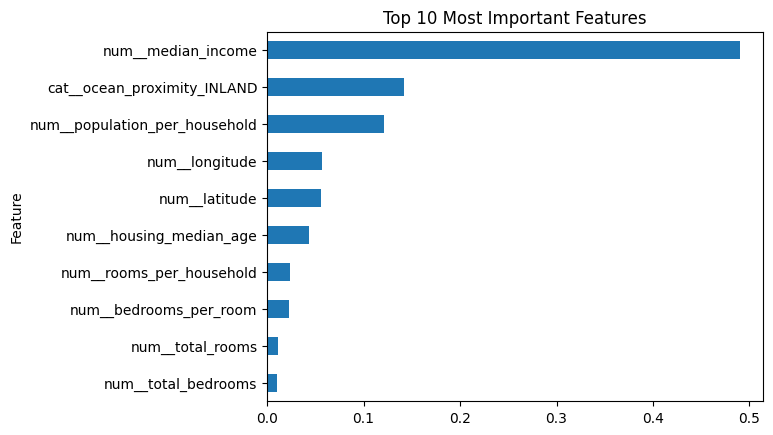

,Feature,Importance
7,num__median_income,0.489731
12,cat__ocean_proximity_INLAND,0.141533
10,num__population_per_household,0.121298
0,num__longitude,0.057302
1,num__latitude,0.055762


In [24]:
# Get feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest
importances = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values("Importance", ascending=False).head(10)

feature_importance.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    title="Top 10 Most Important Features",
    legend=False
)

plt.gca().invert_yaxis()
plt.show()

feature_importance.head(5)

The results confirm that median income is the dominant predictor.

## Unsupervised Learning: KMeans Clustering

In addition to building predictive models, it can be useful to explore whether the dataset contains natural groupings of housing areas. Identifying such groups can help decision makers better understand the structure of the data and segment areas with similar characteristics.

To explore this, we apply KMeans clustering, an unsupervised learning algorithm that groups observations based on similarity across multiple features.

Only the input variables (X) are used for clustering, while the target variable `median_house_value` is excluded. This ensures that the clustering reflects patterns in the explanatory variables rather than the outcome variable.

Before applying the clustering algorithm, several preprocessing steps were required. The categorical variable `ocean_proximity` was converted to dummy variables so that it could be used in numerical analysis. Missing values were handled using median imputation, and all features were standardized. Scaling is important because clustering algorithms rely on distance calculations and are sensitive to differences in feature scales.

In [25]:
X_cluster = X.copy()
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_cluster)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

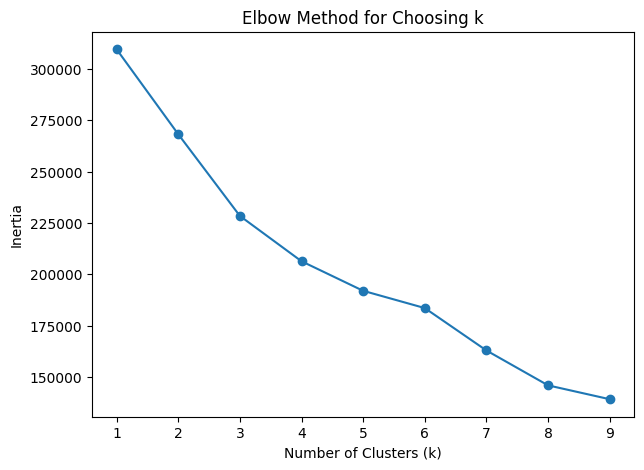

In [26]:
inertia = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")

plt.show()

Choosing the Number of Clusters

To determine a suitable number of clusters, the Elbow Method was used. This method evaluates how the clustering inertia changes as the number of clusters increases.

Inertia measures how tightly grouped the observations are within each cluster. Lower values indicate more compact clusters.

As shown in the plot, inertia decreases rapidly when increasing the number of clusters from one to three. After this point, the decrease becomes more gradual, indicating diminishing returns from adding additional clusters.

This pattern suggests that around **three clusters** provides a reasonable balance between model simplicity and capturing meaningful structure in the data. Therefore, the KMeans model with three clusters was selected for the clustering analysis.

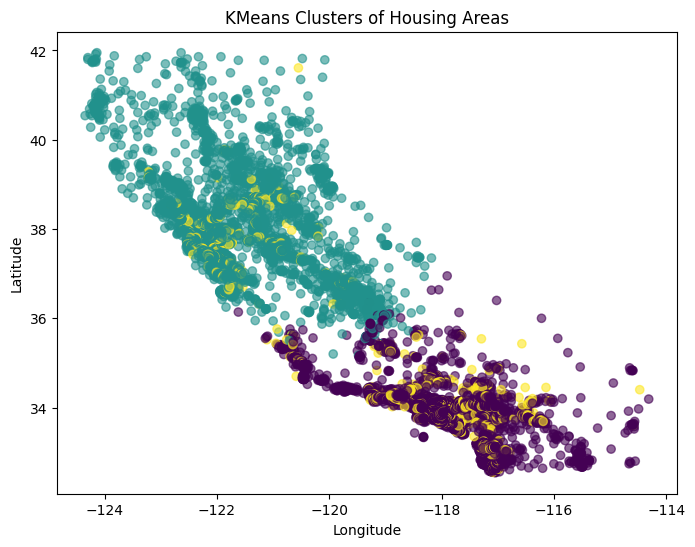

In [27]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

# Create dataframe for visualization
clustered_data = X.copy()
clustered_data["cluster"] = clusters

# Plot clusters geographically
plt.figure(figsize=(8,6))

plt.scatter(
    clustered_data["longitude"],
    clustered_data["latitude"],
    c=clustered_data["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KMeans Clusters of Housing Areas")

plt.show()

In [28]:
cluster_summary = clustered_data.groupby("cluster")[[
    "median_income",
    "rooms_per_household",
    "population_per_household"
]].mean().round(2)

cluster_summary

,median_income,rooms_per_household,population_per_household
cluster,,,
0,3.91,5.19,3.12
1,3.75,5.70,3.06
2,4.25,5.61,2.82


This table helps interpret the clusters by showing average socioeconomic characteristics of each group.

Interpretation of Clusters

The scatter plot visualizes the clusters identified by the KMeans algorithm using geographic coordinates (longitude and latitude). Each point represents a housing district, and the color indicates the cluster to which it belongs.

The clusters appear to follow geographic patterns across California. One group is more concentrated in the southern part of the state, while another appears more common in northern or inland regions. This suggests that areas with similar socioeconomic and housing characteristics tend to be geographically close to one another.

These clusters may represent different types of housing areas with shared characteristics, such as income levels, housing density, or proximity to coastal regions.

From a decision-making perspective, this type of clustering could help segment housing markets into groups of similar districts. Such segmentation could support planning or investment decisions by allowing analysts to compare regions with similar profiles.

However, the clusters should be interpreted with caution. The results depend on the selected features, preprocessing steps, and the chosen number of clusters. Clustering methods identify patterns in the data, but they do not guarantee that the groups correspond to clear real-world categories.

In [29]:
clustered_data["cluster"].value_counts().sort_index()

cluster
0    10709
1     8293
2     1638
Name: count, dtype: int64

The table below shows how many housing districts were assigned to each cluster. The clusters are relatively balanced in size, indicating that the algorithm did not produce a highly skewed grouping where most observations fall into a single cluster.

## Conclusion

In this project, three models were evaluated for predicting housing prices: Linear Regression, Decision Tree, and Random Forest.

Cross-validation results showed that Random Forest consistently achieved the lowest prediction error. After hyperparameter tuning with GridSearchCV, the final model reached a test MAE of approximately 31,758.

Feature importance analysis shows that median_income is the most influential predictor of housing prices, highlighting the importance of economic factors. Geographic variables such as longitude, latitude, and ocean proximity also contribute to the model.

In addition to predictive modeling, KMeans clustering was applied to explore structural patterns in the dataset. The results suggest that districts with similar socioeconomic and geographic characteristics form natural groups.

Overall, Random Forest proved to be the most effective model for this dataset and can be used to estimate housing prices across different districts.